In [1]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\Hp\AntriX\antrix_app\templates
['.ipynb_checkpoints', 'antrix_logo.png', 'antrix_visualizations', 'ANTRIX_Visual_Intelligence_Report.ipynb', 'index.html', 'india_states.geojson']


In [2]:
import os
print(os.listdir('..'))

['antrix_visualizations', 'app.py', 'clusters.csv', 'firms_final.csv', 'templates']


In [3]:
import pandas as pd
df = pd.read_csv('../firms_final.csv')
print('Shape:', df.shape)
print()
print('Columns:')
print(list(df.columns))

Shape: (1283, 45)

Columns:
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'source_sensor', 'brightness', 'bright_t31', 'dist_to_industrial_km', 'grid_lat', 'grid_lon', 'recurrence_days', 'label', 'ml_thermal_score', 'facility_proximity_score', 'persistence_score', 'thermal_intensity_score', 'fusion_score', 'final_label', 'frp_norm', 'recurrence_norm', 'risk_score', 'risk_level', 'baseline_frp', 'frp_deviation_ratio', 'thermal_abnormality', 'persistence_norm', 'industrial_context', 'nearest_facility_lat', 'nearest_facility_lon', 'frp_intensity_norm', 'nearest_facility_name', 'nearest_facility_type', 'cluster_id', 'industrial_evidence_score', 'evidence_level']


In [4]:
print("dtypes:")
print(df.dtypes)
print()
print("final_label counts:")
print(df['final_label'].value_counts())
print()
print("evidence_level counts:")
print(df['evidence_level'].value_counts(dropna=False))
print()
print("acq_date range:")
print(df['acq_date'].min(), "to", df['acq_date'].max())

dtypes:
latitude                     float64
longitude                    float64
bright_ti4                   float64
scan                         float64
track                        float64
acq_date                      object
acq_time                       int64
satellite                     object
instrument                    object
confidence                    object
version                       object
bright_ti5                   float64
frp                          float64
daynight                      object
source_sensor                 object
brightness                   float64
bright_t31                   float64
dist_to_industrial_km        float64
grid_lat                     float64
grid_lon                     float64
recurrence_days                int64
label                         object
ml_thermal_score             float64
facility_proximity_score     float64
persistence_score            float64
thermal_intensity_score      float64
fusion_score                 f

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os

BACKGROUND = "#090812"
TEXT       = "#F4F1F7"
MUTED      = "#918A9F"
VIOLET     = "#A855F7"
MAGENTA    = "#D946EF"
PINK       = "#F43F5E"
ORANGE     = "#FF9F43"
GREY       = "#8B8798"

LABEL_COLORS = {
    "industrial_fire": PINK,
    "persistent_industrial_source": ORANGE,
    "insufficient_evidence": GREY,
}
LABEL_NAMES = {
    "industrial_fire": "Industrial Fire",
    "persistent_industrial_source": "Persistent Industrial Source",
    "insufficient_evidence": "Insufficient Evidence",
}

plt.rcParams.update({
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "savefig.facecolor": BACKGROUND,
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.edgecolor": MUTED,
    "font.size": 11,
})

OUT_DIR = "../antrix_visualizations"
os.makedirs(OUT_DIR, exist_ok=True)

def style_axes(ax, title=None, xlabel=None, ylabel=None):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    for s in ["left", "bottom"]:
        ax.spines[s].set_color(MUTED)
        ax.spines[s].set_alpha(0.3)
    if title:
        ax.set_title(title, color=TEXT, fontsize=15, fontweight="bold", pad=14, loc="left")
    if xlabel:
        ax.set_xlabel(xlabel, color=MUTED, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=10)

print("Style loaded OK")


Style loaded OK


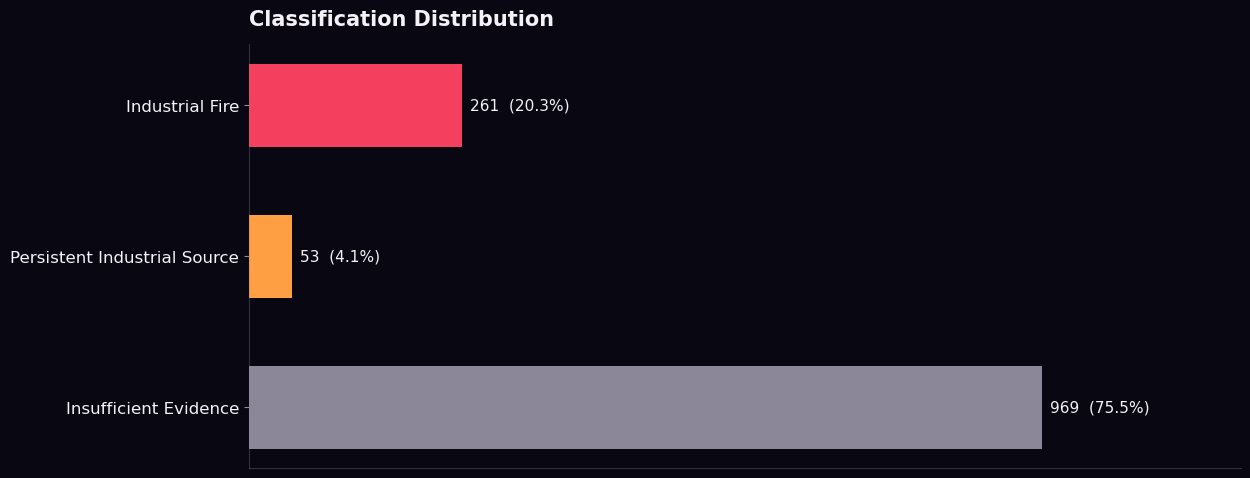

In [6]:
counts = df['final_label'].value_counts()
order = ["industrial_fire", "persistent_industrial_source", "insufficient_evidence"]
counts = counts.reindex(order)
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(12.8, 5.5))
y_pos = np.arange(len(counts))
colors = [LABEL_COLORS[l] for l in counts.index]
bars = ax.barh(y_pos, counts.values, color=colors, height=0.55)
ax.set_yticks(y_pos)
ax.set_yticklabels([LABEL_NAMES[l] for l in counts.index], fontsize=12, color=TEXT)
ax.invert_yaxis()

for bar, c, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_width() + counts.max()*0.01, bar.get_y() + bar.get_height()/2,
            f"{c:,}  ({p:.1f}%)", va="center", fontsize=11, color=TEXT)

ax.set_xlim(0, counts.max() * 1.25)
ax.get_xaxis().set_visible(False)
style_axes(ax, title="Classification Distribution")

plt.savefig(f"{OUT_DIR}/02_classification_distribution.png", dpi=300, bbox_inches="tight", facecolor=BACKGROUND)
plt.show()

In [7]:
try:
    import scipy
    print("scipy:", scipy.__version__)
except ImportError:
    print("scipy: NOT installed")

try:
    import geopandas
    print("geopandas:", geopandas.__version__)
except ImportError:
    print("geopandas: NOT installed")

scipy: 1.13.1
geopandas: NOT installed


In [8]:
import urllib.request
url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_telengana.geojson"
try:
    with urllib.request.urlopen(url, timeout=10) as r:
        print("Status:", r.status, "- internet access OK")
except Exception as e:
    print("Failed:", e)

Status: 200 - internet access OK


In [9]:
import urllib.request
import json

url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_telengana.geojson"
# try the full-country file first
url_full = "https://raw.githubusercontent.com/geohacker/india/master/india_ext.geojson"

for u in [url_full]:
    try:
        with urllib.request.urlopen(u, timeout=15) as r:
            data = json.loads(r.read().decode())
            print("Loaded:", u)
            print("Type:", data.get("type"))
            print("Number of features:", len(data.get("features", [])))
            if data.get("features"):
                print("Sample properties:", data["features"][0].get("properties"))
    except Exception as e:
        print("Failed:", u, "-", e)

Failed: https://raw.githubusercontent.com/geohacker/india/master/india_ext.geojson - HTTP Error 404: Not Found


In [10]:
import urllib.request
import json

url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_state.geojson"
with urllib.request.urlopen(url, timeout=15) as r:
    india_geo = json.loads(r.read().decode())

print("Type:", india_geo.get("type"))
print("Number of features:", len(india_geo.get("features", [])))
print("Sample properties:", india_geo["features"][0].get("properties"))
print("Sample geometry type:", india_geo["features"][0]["geometry"]["type"])

Type: FeatureCollection
Number of features: 35
Sample properties: {'ID_0': 105, 'ISO': 'IND', 'NAME_0': 'India', 'ID_1': 1, 'NAME_1': 'Andaman and Nicobar', 'NL_NAME_1': None, 'VARNAME_1': 'Andaman & Nicobar Islands|Andaman et Nicobar|Iihas de Andama e Nicobar|Inseln Andamanen und Nikobare', 'TYPE_1': 'Union Territor', 'ENGTYPE_1': 'Union Territory'}
Sample geometry type: MultiPolygon


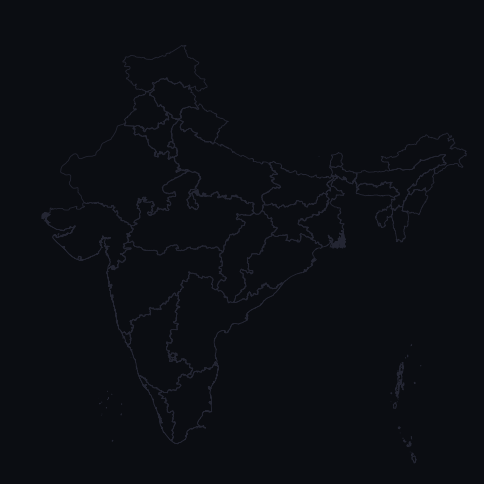

In [65]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path
import numpy as np

with open("india_states.geojson", "w") as f:
    json.dump(india_geo, f)

def geojson_to_patches(geojson, edgecolor="#242633", linewidth=0.6, facecolor="none", zorder=2):
    patches = []
    for feature in geojson["features"]:
        geom = feature["geometry"]
        polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
        for poly in polys:
            exterior = np.array(poly[0])
            codes = [Path.MOVETO] + [Path.LINETO] * (len(exterior) - 2) + [Path.CLOSEPOLY]
            vertices = list(exterior)
            for hole in poly[1:]:
                hole = np.array(hole)
                codes += [Path.MOVETO] + [Path.LINETO] * (len(hole) - 2) + [Path.CLOSEPOLY]
                vertices += list(hole)
            patches.append(PathPatch(Path(vertices, codes), facecolor=facecolor,
                                      edgecolor=edgecolor, linewidth=linewidth, zorder=zorder))
    return patches

fig, ax = plt.subplots(figsize=(6, 7), facecolor="#0B0D12")
ax.set_facecolor("#0B0D12")
for p in geojson_to_patches(india_geo):
    ax.add_patch(p)
ax.set_xlim(66, 98)
ax.set_ylim(6, 38)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

In [12]:
import pandas as pd
import os

candidates = ["firms_with_features.csv", "firms_labeled.csv", "firms_with_distance.csv"]
for fname in candidates:
    if os.path.exists(fname):
        head = pd.read_csv(fname, nrows=3)
        nrows = sum(1 for _ in open(fname)) - 1
        size_kb = os.path.getsize(fname) / 1024
        print(f"\n{fname} — {nrows} rows, {size_kb:.0f} KB")
        print(list(head.columns))
    else:
        print(f"{fname}: not found")

firms_with_features.csv: not found
firms_labeled.csv: not found
firms_with_distance.csv: not found


In [64]:
import os

for fname in sorted(os.listdir(".")):
    if fname.lower().endswith(".csv"):
        size_kb = os.path.getsize(fname) / 1024
        print(f"{fname:40s} {size_kb:10.1f} KB")

In [63]:
import os
print("Notebook working directory:", os.getcwd())

Notebook working directory: C:\Users\Hp\AntriX\antrix_app\templates


In [15]:
import os
import pandas as pd

DATA_DIR = r"C:\Users\Hp\OneDrive\Desktop\FeeReact\CASHIQ_1\Backend"

print("Exists:", os.path.isdir(DATA_DIR))

for fname in sorted(os.listdir(DATA_DIR)):
    if fname.lower().endswith(".csv"):
        full = os.path.join(DATA_DIR, fname)
        print(f"{fname:30s} {os.path.getsize(full)/1024:8.1f} KB")

Exists: False


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\Hp\\OneDrive\\Desktop\\FeeReact\\CASHIQ_1\\Backend'

In [62]:
import os

roots_to_try = [
    r"C:\Users\Hp\OneDrive\Desktop",
    r"C:\Users\Hp\Desktop",
    r"C:\Users\Hp",
]

target = "firms_labeled.csv"

for root in roots_to_try:
    if not os.path.isdir(root):
        print(f"[missing] {root}")
        continue
    print(f"[searching] {root}")
    for dirpath, dirs, files in os.walk(root):
        # skip noisy folders to keep this fast
        dirs[:] = [d for d in dirs if d.lower() not in
                   ("node_modules", ".git", "__pycache__", ".ipynb_checkpoints", "venv", ".venv")]
        if target in files:
            print("FOUND:", os.path.join(dirpath, target))

[searching] C:\Users\Hp\OneDrive\Desktop
[missing] C:\Users\Hp\Desktop
[searching] C:\Users\Hp
FOUND: C:\Users\Hp\AntriX\firms_labeled.csv


In [60]:
import os

root = r"C:\Users\Hp\AntriX"
target_names = {"firms_labeled.csv", "firms_with_distance.csv", "firms_with_features.csv",
                 "firms_final.csv", "firms_raw.csv"}

found = []
for dirpath, dirs, files in os.walk(root):
    dirs[:] = [d for d in dirs if d.lower() not in
               ("node_modules", ".git", "__pycache__", ".ipynb_checkpoints", "venv", ".venv")]
    for f in files:
        if f in target_names:
            full = os.path.join(dirpath, f)
            found.append(full)
            print(f"{full}   ({os.path.getsize(full)/1024:.1f} KB)")

if not found:
    print("Nothing found under", root)

C:\Users\Hp\AntriX\firms_final.csv   (509.9 KB)
C:\Users\Hp\AntriX\firms_labeled.csv   (183.6 KB)
C:\Users\Hp\AntriX\firms_raw.csv   (126.1 KB)
C:\Users\Hp\AntriX\firms_with_distance.csv   (149.2 KB)
C:\Users\Hp\AntriX\firms_with_features.csv   (166.0 KB)
C:\Users\Hp\AntriX\antrix_app\firms_final.csv   (509.9 KB)


In [58]:
import os
import pandas as pd

DATA_DIR = r"C:\Users\Hp\AntriX"

for fname in ["firms_labeled.csv", "firms_with_distance.csv", "firms_with_features.csv", "firms_raw.csv"]:
    full = os.path.join(DATA_DIR, fname)
    df_head = pd.read_csv(full, nrows=3)
    print(f"\n{fname} — {os.path.getsize(full)/1024:.1f} KB")
    print(list(df_head.columns))


firms_labeled.csv — 183.6 KB
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'source_sensor', 'brightness', 'bright_t31', 'dist_to_industrial_km', 'grid_lat', 'grid_lon', 'recurrence_days', 'label']

firms_with_distance.csv — 149.2 KB
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'source_sensor', 'brightness', 'bright_t31', 'dist_to_industrial_km']

firms_with_features.csv — 166.0 KB
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'source_sensor', 'brightness', 'bright_t31', 'dist_to_industrial_km', 'grid_lat', 'grid_lon', 'recurrence_days']

firms_raw.csv — 126.1 KB
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 

In [56]:
import os
import pandas as pd

DATA_DIR = r"C:\Users\Hp\AntriX"
firms = pd.read_csv(os.path.join(DATA_DIR, "firms_raw.csv"))

print("Rows:", len(firms))
print("Lat range:", firms.latitude.min(), "to", firms.latitude.max())
print("Lon range:", firms.longitude.min(), "to", firms.longitude.max())
print("FRP range:", firms.frp.min(), "to", firms.frp.max())
print("Missing lat/lon:", firms[["latitude","longitude"]].isna().sum().sum())

Rows: 1283
Lat range: 8.0151 to 31.53478
Lon range: 68.06085 to 89.81267
FRP range: 0.22 to 407.79
Missing lat/lon: 0


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import PathPatch
from matplotlib.path import Path
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

# ---- palette ----
BG        = "#0B0D12"
TEXT      = "#F5F3FF"
MUTED     = "#9693A8"
BORDER    = "#242633"
thermal_colors = ["#0B0D12", "#9B5CFF", "#E84DFF", "#FF9F43", "#FF4D6D"]
thermal_cmap = LinearSegmentedColormap.from_list("antrix_thermal", thermal_colors, N=256)

# ---- geometry helper (from earlier) ----
def geojson_to_patches(geojson, edgecolor=BORDER, linewidth=0.5, facecolor="none", zorder=3):
    patches = []
    for feature in geojson["features"]:
        geom = feature["geometry"]
        polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
        for poly in polys:
            exterior = np.array(poly[0])
            codes = [Path.MOVETO] + [Path.LINETO]*(len(exterior)-2) + [Path.CLOSEPOLY]
            vertices = list(exterior)
            for hole in poly[1:]:
                hole = np.array(hole)
                codes += [Path.MOVETO] + [Path.LINETO]*(len(hole)-2) + [Path.CLOSEPOLY]
                vertices += list(hole)
            patches.append(PathPatch(Path(vertices, codes), facecolor=facecolor,
                                      edgecolor=edgecolor, linewidth=linewidth,
                                      zorder=zorder, alpha=0.9))
    return patches

# ---- KDE density field over India's bounding box ----
lon = firms["longitude"].values
lat = firms["latitude"].values

xmin, xmax = 67.5, 98.5
ymin, ymax = 6.5, 37.5

xx, yy = np.mgrid[xmin:xmax:400j, ymin:ymax:400j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([lon, lat])
kernel = gaussian_kde(values, bw_method=0.12)
density = np.reshape(kernel(positions).T, xx.shape)

# ---- figure ----
fig, ax = plt.subplots(figsize=(9, 11), facecolor=BG)
ax.set_facecolor(BG)

# density field, clipped visually to look like a glow rather than a hard block
im = ax.imshow(np.rot90(density), extent=[xmin, xmax, ymin, ymax],
               cmap=thermal_cmap, origin="upper", zorder=2,
               alpha=0.95, interpolation="bilinear")

# state/country boundaries on top, subtle
for p in geojson_to_patches(india_geo):
    ax.add_patch(p)

# clip the density image to India's silhouette so it doesn't spill into the ocean/neighbours
from matplotlib.patches import PathPatch as ClipPatch
all_paths = []
for feature in india_geo["features"]:
    geom = feature["geometry"]
    polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
    for poly in polys:
        ext = np.array(poly[0])
        codes = [Path.MOVETO] + [Path.LINETO]*(len(ext)-2) + [Path.CLOSEPOLY]
        all_paths.append(Path(ext, codes))
compound_path = Path.make_compound_path(*all_paths)
clip = PathPatch(compound_path, transform=ax.transData)
im.set_clip_path(clip)

# actual detections as small precise points, very subtle, on top of the glow
ax.scatter(lon, lat, s=3, color="#F5F3FF", alpha=0.15, linewidths=0, zorder=4)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.axis("off")

# ---- typography ----
fig.text(0.08, 0.955, "THERMAL ACTIVITY ACROSS INDIA",
          fontsize=22, fontweight="bold", color=TEXT, ha="left", family="sans-serif")
fig.text(0.08, 0.935, "Satellite detections processed by ANTRIX",
          fontsize=12, color=MUTED, ha="left", family="sans-serif")
fig.text(0.08, 0.02, f"{len(firms):,} VIIRS/MODIS detections  ·  {firms['acq_date'].min()} to {firms['acq_date'].max()}",
          fontsize=9.5, color=MUTED, ha="left", family="sans-serif")

NameError: name 'firms' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(9, 12), facecolor=BG)
fig.subplots_adjust(top=0.90, bottom=0.06, left=0.06, right=0.94)
ax.set_facecolor(BG)
# ... (all the density/clip/scatter code stays the same) ...

fig.text(0.06, 0.965, "THERMAL ACTIVITY ACROSS INDIA",
          fontsize=22, fontweight="bold", color=TEXT, ha="left")
fig.text(0.06, 0.945, "Satellite detections processed by ANTRIX",
          fontsize=12, color=MUTED, ha="left")
fig.text(0.06, 0.02, f"{len(firms):,} VIIRS/MODIS detections  ·  {firms['acq_date'].min()} to {firms['acq_date'].max()}",
          fontsize=9.5, color=MUTED, ha="left")

plt.savefig("antrix_visualizations/01_india_thermal_activity.png",
            dpi=300, facecolor=BG)   # no bbox_inches="tight" this time
plt.savefig("antrix_visualizations/01_india_thermal_activity.svg", facecolor=BG)
plt.show()

In [ ]:
import os

os.makedirs("antrix_visualizations", exist_ok=True)

plt.savefig("antrix_visualizations/01_india_thermal_activity.png",
            dpi=300, facecolor=BG)
plt.savefig("antrix_visualizations/01_india_thermal_activity.svg", facecolor=BG)
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

BG        = "#0B0D12"
TEXT      = "#F5F3FF"
MUTED     = "#9693A8"
BORDER    = "#242633"
thermal_colors = ["#0B0D12", "#9B5CFF", "#E84DFF", "#FF9F43", "#FF4D6D"]
thermal_cmap = LinearSegmentedColormap.from_list("antrix_thermal", thermal_colors, N=256)

def geojson_to_patches(geojson, edgecolor=BORDER, linewidth=0.5, facecolor="none", zorder=3):
    patches = []
    for feature in geojson["features"]:
        geom = feature["geometry"]
        polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
        for poly in polys:
            exterior = np.array(poly[0])
            codes = [Path.MOVETO] + [Path.LINETO]*(len(exterior)-2) + [Path.CLOSEPOLY]
            vertices = list(exterior)
            for hole in poly[1:]:
                hole = np.array(hole)
                codes += [Path.MOVETO] + [Path.LINETO]*(len(hole)-2) + [Path.CLOSEPOLY]
                vertices += list(hole)
            patches.append(PathPatch(Path(vertices, codes), facecolor=facecolor,
                                      edgecolor=edgecolor, linewidth=linewidth,
                                      zorder=zorder, alpha=0.9))
    return patches

lon = firms["longitude"].values
lat = firms["latitude"].values

xmin, xmax = 67.5, 98.5
ymin, ymax = 6.5, 37.5

xx, yy = np.mgrid[xmin:xmax:400j, ymin:ymax:400j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([lon, lat])
kernel = gaussian_kde(values, bw_method=0.12)
density = np.reshape(kernel(positions).T, xx.shape)

fig, ax = plt.subplots(figsize=(9, 12), facecolor=BG)
fig.subplots_adjust(top=0.90, bottom=0.06, left=0.06, right=0.94)
ax.set_facecolor(BG)

im = ax.imshow(np.rot90(density), extent=[xmin, xmax, ymin, ymax],
               cmap=thermal_cmap, origin="upper", zorder=2,
               alpha=0.95, interpolation="bilinear")

for p in geojson_to_patches(india_geo):
    ax.add_patch(p)

all_paths = []
for feature in india_geo["features"]:
    geom = feature["geometry"]
    polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
    for poly in polys:
        ext = np.array(poly[0])
        codes = [Path.MOVETO] + [Path.LINETO]*(len(ext)-2) + [Path.CLOSEPOLY]
        all_paths.append(Path(ext, codes))
compound_path = Path.make_compound_path(*all_paths)
clip = PathPatch(compound_path, transform=ax.transData)
im.set_clip_path(clip)

ax.scatter(lon, lat, s=3, color="#F5F3FF", alpha=0.15, linewidths=0, zorder=4)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.axis("off")

fig.text(0.06, 0.965, "THERMAL ACTIVITY ACROSS INDIA",
          fontsize=22, fontweight="bold", color=TEXT, ha="left")
fig.text(0.06, 0.945, "Satellite detections processed by ANTRIX",
          fontsize=12, color=MUTED, ha="left")
fig.text(0.06, 0.02, f"{len(firms):,} VIIRS/MODIS detections  ·  {firms['acq_date'].min()} to {firms['acq_date'].max()}",
          fontsize=9.5, color=MUTED, ha="left")

os.makedirs("antrix_visualizations", exist_ok=True)
plt.savefig("antrix_visualizations/01_india_thermal_activity.png", dpi=300, facecolor=BG)
plt.savefig("antrix_visualizations/01_india_thermal_activity.svg", facecolor=BG)
plt.show()

In [ ]:
import time
import numpy as np
from scipy.ndimage import gaussian_filter

t0 = time.time()

lon = firms["longitude"].values
lat = firms["latitude"].values

xmin, xmax = 67.5, 98.5
ymin, ymax = 6.5, 37.5
grid_n = 400

# bin the raw points into a 2D histogram — this is just counting, extremely fast
hist, xedges, yedges = np.histogram2d(
    lon, lat, bins=grid_n, range=[[xmin, xmax], [ymin, ymax]]
)

# smooth it into a continuous glow — also very fast, pure convolution
density = gaussian_filter(hist, sigma=8)

print("density built in:", time.time() - t0, "s")

In [ ]:
import os
import json
import pandas as pd

DATA_DIR = r"C:\Users\Hp\AntriX"

# reload the lightweight firms data
firms = pd.read_csv(os.path.join(DATA_DIR, "firms_raw.csv"))
print("firms loaded:", len(firms), "rows")

# reload the cached india state boundaries (saved earlier as india_states.geojson)
geojson_path = "india_states.geojson"
if os.path.exists(geojson_path):
    with open(geojson_path) as f:
        india_geo = json.load(f)
    print("india_geo loaded from cache:", len(india_geo["features"]), "features")
else:
    print("Cached geojson not found at:", os.path.abspath(geojson_path))
    print("Re-fetch it with urllib as before, or tell me and I'll give you that cell again.")

In [ ]:
import time
import numpy as np
from scipy.ndimage import gaussian_filter

t0 = time.time()

lon = firms["longitude"].values
lat = firms["latitude"].values

xmin, xmax = 67.5, 98.5
ymin, ymax = 6.5, 37.5
grid_n = 400

hist, xedges, yedges = np.histogram2d(
    lon, lat, bins=grid_n, range=[[xmin, xmax], [ymin, ymax]]
)

density = gaussian_filter(hist, sigma=8)

print("density built in:", time.time() - t0, "s")

In [34]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from PIL import Image, ImageDraw

# ---- palette ----
BG        = "#0B0D12"
TEXT      = "#F5F3FF"
MUTED     = "#9693A8"
BORDER    = "#242633"
thermal_colors = ["#0B0D12", "#9B5CFF", "#E84DFF", "#FF9F43", "#FF4D6D"]
thermal_cmap = LinearSegmentedColormap.from_list("antrix_thermal", thermal_colors, N=256)

# ---- geometry helper: geojson polygons -> matplotlib patches (state lines) ----
def geojson_to_patches(geojson, edgecolor=BORDER, linewidth=0.5, facecolor="none", zorder=3):
    patches = []
    for feature in geojson["features"]:
        geom = feature["geometry"]
        polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
        for poly in polys:
            exterior = np.array(poly[0])
            codes = [Path.MOVETO] + [Path.LINETO]*(len(exterior)-2) + [Path.CLOSEPOLY]
            vertices = list(exterior)
            for hole in poly[1:]:
                hole = np.array(hole)
                codes += [Path.MOVETO] + [Path.LINETO]*(len(hole)-2) + [Path.CLOSEPOLY]
                vertices += list(hole)
            patches.append(PathPatch(Path(vertices, codes), facecolor=facecolor,
                                      edgecolor=edgecolor, linewidth=linewidth,
                                      zorder=zorder, alpha=0.9))
    return patches

t_total = time.time()

lon = firms["longitude"].values
lat = firms["latitude"].values

xmin, xmax = 67.5, 98.5
ymin, ymax = 6.5, 37.5
grid_n = 400

# ---- fast density field: histogram + gaussian blur ----
hist, xedges, yedges = np.histogram2d(
    lon, lat, bins=grid_n, range=[[xmin, xmax], [ymin, ymax]]
)
density = gaussian_filter(hist, sigma=8)
density = density.T  # so orientation matches lon=x, lat=y when imshow'd

# ---- figure ----
fig, ax = plt.subplots(figsize=(9, 12), facecolor=BG)
fig.subplots_adjust(top=0.90, bottom=0.06, left=0.06, right=0.94)
ax.set_facecolor(BG)

im = ax.imshow(density, extent=[xmin, xmax, ymin, ymax],
               cmap=thermal_cmap, origin="lower", zorder=2,
               alpha=0.95, interpolation="bilinear")

# subtle internal state boundaries
for p in geojson_to_patches(india_geo):
    ax.add_patch(p)

# ---- compound path of all state polygons, used for clipping the glow ----
all_paths = []
for feature in india_geo["features"]:
    geom = feature["geometry"]
    polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
    for poly in polys:
        ext = np.array(poly[0])
        codes = [Path.MOVETO] + [Path.LINETO]*(len(ext)-2) + [Path.CLOSEPOLY]
        all_paths.append(Path(ext, codes))
compound_path = Path.make_compound_path(*all_paths)

clip = PathPatch(compound_path, transform=ax.transData)
im.set_clip_path(clip)

# ---- bright white outer country outline via fast PIL rasterization ----
mask_grid_n = 900

def lonlat_to_px(lon_, lat_, xmin_, xmax_, ymin_, ymax_, w, h):
    px = (lon_ - xmin_) / (xmax_ - xmin_) * w
    py = (ymax_ - lat_) / (ymax_ - ymin_) * h
    return px, py

mask_img = Image.new("L", (mask_grid_n, mask_grid_n), 0)
draw = ImageDraw.Draw(mask_img)
for feature in india_geo["features"]:
    geom = feature["geometry"]
    polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
    for poly in polys:
        ext = np.array(poly[0])
        pts = [lonlat_to_px(x, y, xmin, xmax, ymin, ymax, mask_grid_n, mask_grid_n) for x, y in ext]
        draw.polygon(pts, fill=255)

inside_mask = np.array(mask_img) > 0

gx = np.linspace(xmin, xmax, mask_grid_n)
gy = np.linspace(ymax, ymin, mask_grid_n)
GX, GY = np.meshgrid(gx, gy)

ax.contour(GX, GY, inside_mask.astype(float), levels=[0.5],
           colors="#F5F3FF", linewidths=1.3, zorder=5, alpha=0.9)

# faint discrete detection points on top of the glow
ax.scatter(lon, lat, s=3, color="#F5F3FF", alpha=0.15, linewidths=0, zorder=6)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.axis("off")

# ---- typography ----
fig.text(0.06, 0.965, "THERMAL ACTIVITY ACROSS INDIA",
          fontsize=22, fontweight="bold", color=TEXT, ha="left")
fig.text(0.06, 0.945, "Satellite detections processed by ANTRIX",
          fontsize=12, color=MUTED, ha="left")
fig.text(0.06, 0.035,
          f"{len(firms):,} VIIRS/MODIS detections  ·  {firms['acq_date'].min()} to {firms['acq_date'].max()}",
          fontsize=9.5, color=MUTED, ha="left")

# ---- save ----
os.makedirs("antrix_visualizations", exist_ok=True)
plt.savefig("antrix_visualizations/01_india_thermal_activity.png", dpi=300, facecolor=BG)
plt.savefig("antrix_visualizations/01_india_thermal_activity.svg", facecolor=BG)

print(f"Total time: {time.time() - t_total:.2f}s")
plt.show()

NameError: name 'firms' is not defined

In [52]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from PIL import Image, ImageDraw

# ---- palette ----
BG        = "#0B0D12"
TEXT      = "#F5F3FF"
MUTED     = "#9693A8"
BORDER    = "#242633"
thermal_colors = ["#0B0D12", "#9B5CFF", "#E84DFF", "#FF9F43", "#FF4D6D"]
thermal_cmap = LinearSegmentedColormap.from_list("antrix_thermal", thermal_colors, N=256)

# ---- geometry helper: geojson polygons -> matplotlib patches (state lines) ----
def geojson_to_patches(geojson, edgecolor=BORDER, linewidth=0.5, facecolor="none", zorder=3):
    patches = []
    for feature in geojson["features"]:
        geom = feature["geometry"]
        polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
        for poly in polys:
            exterior = np.array(poly[0])
            codes = [Path.MOVETO] + [Path.LINETO]*(len(exterior)-2) + [Path.CLOSEPOLY]
            vertices = list(exterior)
            for hole in poly[1:]:
                hole = np.array(hole)
                codes += [Path.MOVETO] + [Path.LINETO]*(len(hole)-2) + [Path.CLOSEPOLY]
                vertices += list(hole)
            patches.append(PathPatch(Path(vertices, codes), facecolor=facecolor,
                                      edgecolor=edgecolor, linewidth=linewidth,
                                      zorder=zorder, alpha=0.9))
    return patches

t_total = time.time()

lon = firms["longitude"].values
lat = firms["latitude"].values

xmin, xmax = 67.5, 98.5
ymin, ymax = 6.5, 37.5
grid_n = 400

# ---- fast density field: histogram + gaussian blur ----
hist, xedges, yedges = np.histogram2d(
    lon, lat, bins=grid_n, range=[[xmin, xmax], [ymin, ymax]]
)
density = gaussian_filter(hist, sigma=8)
density = density.T

# ---- figure ----
fig, ax = plt.subplots(figsize=(9, 12), facecolor=BG)
ax.set_facecolor(BG)

im = ax.imshow(density, extent=[xmin, xmax, ymin, ymax],
               cmap=thermal_cmap, origin="lower", zorder=2,
               alpha=0.95, interpolation="bilinear")

# subtle internal state boundaries
for p in geojson_to_patches(india_geo):
    ax.add_patch(p)

# ---- compound path of all state polygons, used for clipping the glow ----
all_paths = []
for feature in india_geo["features"]:
    geom = feature["geometry"]
    polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
    for poly in polys:
        ext = np.array(poly[0])
        codes = [Path.MOVETO] + [Path.LINETO]*(len(ext)-2) + [Path.CLOSEPOLY]
        all_paths.append(Path(ext, codes))
compound_path = Path.make_compound_path(*all_paths)

clip = PathPatch(compound_path, transform=ax.transData)
im.set_clip_path(clip)

# ---- bright white outer country outline via fast PIL rasterization ----
mask_grid_n = 900

def lonlat_to_px(lon_, lat_, xmin_, xmax_, ymin_, ymax_, w, h):
    px = (lon_ - xmin_) / (xmax_ - xmin_) * w
    py = (ymax_ - lat_) / (ymax_ - ymin_) * h
    return px, py

mask_img = Image.new("L", (mask_grid_n, mask_grid_n), 0)
draw = ImageDraw.Draw(mask_img)
for feature in india_geo["features"]:
    geom = feature["geometry"]
    polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
    for poly in polys:
        ext = np.array(poly[0])
        pts = [lonlat_to_px(x, y, xmin, xmax, ymin, ymax, mask_grid_n, mask_grid_n) for x, y in ext]
        draw.polygon(pts, fill=255)

inside_mask = np.array(mask_img) > 0

gx = np.linspace(xmin, xmax, mask_grid_n)
gy = np.linspace(ymax, ymin, mask_grid_n)
GX, GY = np.meshgrid(gx, gy)

ax.contour(GX, GY, inside_mask.astype(float), levels=[0.5],
           colors="#F5F3FF", linewidths=1.3, zorder=5, alpha=0.9)

# faint discrete detection points on top of the glow
ax.scatter(lon, lat, s=3, color="#F5F3FF", alpha=0.15, linewidths=0, zorder=6)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_anchor("N")

# ---- pin the axes box so equal-aspect scaling can't eat into the title margin ----
ax.set_position([0.06, 0.06, 0.88, 0.80])

ax.axis("off")

# ---- typography ----
fig.text(0.06, 0.965, "THERMAL ACTIVITY ACROSS INDIA",
          fontsize=22, fontweight="bold", color=TEXT, ha="left")
fig.text(0.06, 0.945, "Satellite detections processed by ANTRIX",
          fontsize=12, color=MUTED, ha="left")
fig.text(0.06, 0.025,
          f"{len(firms):,} VIIRS/MODIS detections  ·  {firms['acq_date'].min()} to {firms['acq_date'].max()}",
          fontsize=9.5, color=MUTED, ha="left")

# ---- save ----
os.makedirs("antrix_visualizations", exist_ok=True)
plt.savefig("antrix_visualizations/01_india_thermal_activity.png", dpi=300, facecolor=BG)
plt.savefig("antrix_visualizations/01_india_thermal_activity.svg", facecolor=BG)

print(f"Total time: {time.time() - t_total:.2f}s")
print("Axes position:", ax.get_position())
plt.show()

NameError: name 'firms' is not defined

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\Hp\AntriX"
labeled = pd.read_csv(os.path.join(DATA_DIR, "firms_labeled.csv"))

counts = labeled["label"].value_counts()
total = counts.sum()
print(counts)
print((counts / total * 100).round(1))

label
unknown_other          1074
industrial              128
possible_industrial      81
Name: count, dtype: int64
label
unknown_other          83.7
industrial             10.0
possible_industrial     6.3
Name: count, dtype: float64


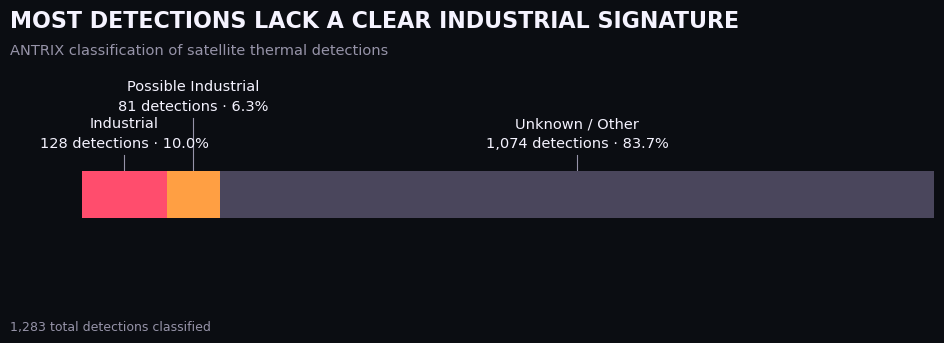

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\Hp\AntriX"
labeled = pd.read_csv(os.path.join(DATA_DIR, "firms_labeled.csv"))

counts = labeled["label"].value_counts()
total = counts.sum()

# order matters for the strip: most-actionable first, majority/unknown last
order = ["industrial", "possible_industrial", "unknown_other"]
counts = counts.reindex(order)

labels_display = {
    "industrial": "Industrial",
    "possible_industrial": "Possible Industrial",
    "unknown_other": "Unknown / Other",
}
colors = {
    "industrial": "#FF4D6D",
    "possible_industrial": "#FF9F43",
    "unknown_other": "#4A465C",   # muted violet-gray, not a "hot" color
}

BG    = "#0B0D12"
TEXT  = "#F5F3FF"
MUTED = "#9693A8"

fig, ax = plt.subplots(figsize=(11, 3.4), facecolor=BG)
ax.set_facecolor(BG)

bar_y = 0.35
bar_h = 0.18
x = 0.0

# stagger label heights so adjacent narrow segments don't overlap
label_offsets = [0.06, 0.20, 0.06]  # cycles per segment in `order`

for i, cat in enumerate(order):
    w = counts[cat] / total
    ax.add_patch(plt.Rectangle((x, bar_y), w, bar_h,
                                facecolor=colors[cat], edgecolor="none", zorder=2))
    mid_x = x + w / 2
    offset = label_offsets[i % len(label_offsets)]
    label_y = bar_y + bar_h + offset

    ax.plot([mid_x, mid_x], [bar_y + bar_h, label_y], color=MUTED, lw=0.8, zorder=1)
    pct = counts[cat] / total * 100
    ax.text(mid_x, label_y + 0.02,
            f"{labels_display[cat]}\n{counts[cat]:,} detections · {pct:.1f}%",
            ha="center", va="bottom", color=TEXT, fontsize=10.5, linespacing=1.5)
    x += w

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

fig.text(0.06, 0.94, "MOST DETECTIONS LACK A CLEAR INDUSTRIAL SIGNATURE",
          fontsize=16, fontweight="bold", color=TEXT, ha="left")
fig.text(0.06, 0.86, "ANTRIX classification of satellite thermal detections",
          fontsize=10.5, color=MUTED, ha="left")
fig.text(0.06, 0.05, f"{total:,} total detections classified",
          fontsize=9, color=MUTED, ha="left")

os.makedirs("antrix_visualizations", exist_ok=True)
plt.savefig("antrix_visualizations/02_classification_distribution.png",
            dpi=300, facecolor=BG, bbox_inches="tight")
plt.savefig("antrix_visualizations/02_classification_distribution.svg",
            facecolor=BG, bbox_inches="tight")
plt.show()

In [40]:
import os
import pandas as pd

DATA_DIR = r"C:\Users\Hp\AntriX"
labeled = pd.read_csv(os.path.join(DATA_DIR, "firms_labeled.csv"))

thermal_cols = ["frp", "bright_ti4", "bright_ti5", "brightness", "bright_t31"]

print("Missing values:")
print(labeled[thermal_cols].isna().sum())

print("\nOverall stats:")
print(labeled[thermal_cols].describe())

print("\nRows per category (for sample-size sanity):")
print(labeled["label"].value_counts())

print("\nFRP stats by category:")
print(labeled.groupby("label")["frp"].describe())

Missing values:
frp              0
bright_ti4      69
bright_ti5      69
brightness    1214
bright_t31    1214
dtype: int64

Overall stats:
               frp   bright_ti4   bright_ti5  brightness  bright_t31
count  1283.000000  1214.000000  1214.000000   69.000000   69.000000
mean      5.292214   322.947471   290.894481  315.251594  293.236667
std      18.053179    16.996408     8.852647   12.823393    5.201249
min       0.220000   207.930000   261.360000  301.570000  278.890000
25%       1.490000   306.602500   286.030000  307.150000  290.390000
50%       2.800000   329.370000   291.120000  312.170000  293.920000
75%       5.145000   336.892500   296.997500  318.320000  296.270000
max     407.790000   367.000000   311.740000  372.480000  302.940000

Rows per category (for sample-size sanity):
label
unknown_other          1074
industrial              128
possible_industrial      81
Name: count, dtype: int64

FRP stats by category:
                      count      mean        std   min

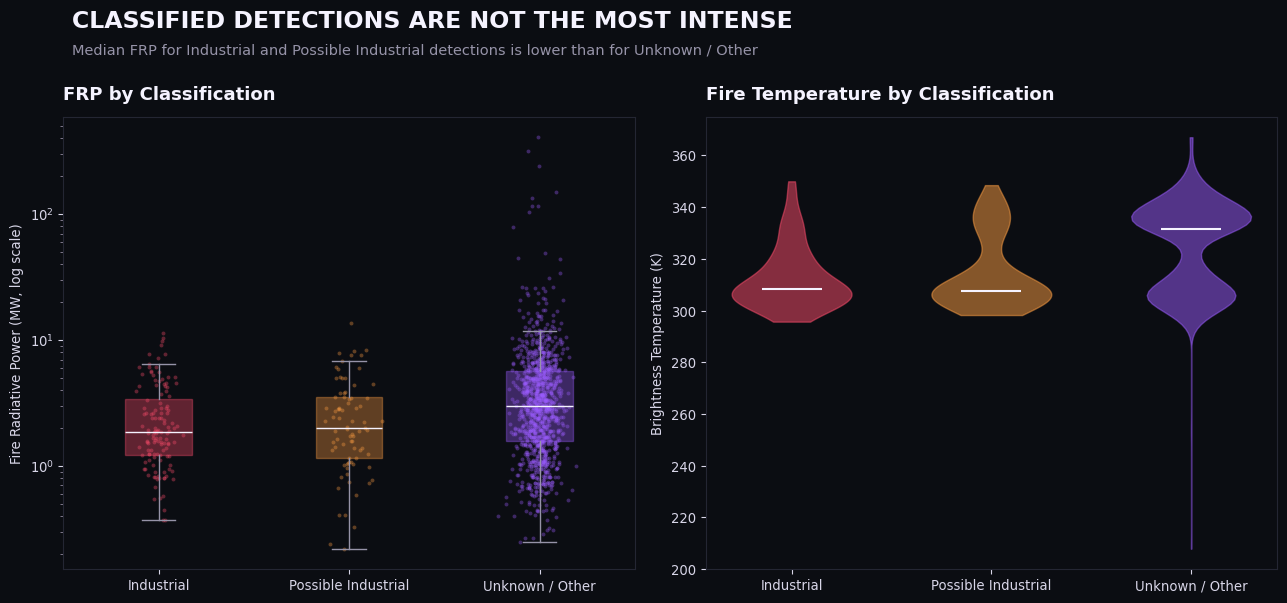

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\Hp\AntriX"
labeled = pd.read_csv(os.path.join(DATA_DIR, "firms_labeled.csv"))

order = ["industrial", "possible_industrial", "unknown_other"]
labels_display = {"industrial": "Industrial", "possible_industrial": "Possible Industrial",
                   "unknown_other": "Unknown / Other"}
colors = {"industrial": "#FF4D6D", "possible_industrial": "#FF9F43", "unknown_other": "#9B5CFF"}

BG, TEXT, MUTED, BORDER = "#0B0D12", "#F5F3FF", "#9693A8", "#242633"
LABEL = "#D8D6E8"  # brighter than MUTED, for axis labels/ticks

fig, axes = plt.subplots(1, 2, figsize=(13, 6), facecolor=BG)

# ---- Panel A: FRP, log scale, box + jittered strip ----
ax = axes[0]
ax.set_facecolor(BG)
data_frp = [labeled.loc[labeled["label"] == c, "frp"].values for c in order]

bp = ax.boxplot(data_frp, positions=range(len(order)), widths=0.35,
                 patch_artist=True, showfliers=False, zorder=3)
for i, c in enumerate(order):
    bp["boxes"][i].set_facecolor(colors[c])
    bp["boxes"][i].set_alpha(0.35)
    bp["boxes"][i].set_edgecolor(colors[c])
    bp["medians"][i].set_color(TEXT)
    bp["whiskers"][2*i].set_color(MUTED)
    bp["whiskers"][2*i+1].set_color(MUTED)
    bp["caps"][2*i].set_color(MUTED)
    bp["caps"][2*i+1].set_color(MUTED)

rng = np.random.default_rng(42)
for i, c in enumerate(order):
    y = data_frp[i]
    x_jitter = rng.normal(i, 0.06, size=len(y))
    ax.scatter(x_jitter, y, s=8, color=colors[c], alpha=0.35, linewidths=0, zorder=2)

ax.set_yscale("log")
ax.set_xticks(range(len(order)))
ax.set_xticklabels([labels_display[c] for c in order], color=TEXT, fontsize=10.5)
ax.set_ylabel("Fire Radiative Power (MW, log scale)", color=LABEL, fontsize=9.5)
ax.tick_params(colors=LABEL, labelsize=9.5)
for spine in ax.spines.values():
    spine.set_color(BORDER)
ax.set_title("FRP by Classification", color=TEXT, fontsize=13, fontweight="bold", loc="left", pad=12)

# ---- Panel B: bright_ti4, violin by category ----
ax2 = axes[1]
ax2.set_facecolor(BG)
data_bt = [labeled.loc[labeled["label"] == c, "bright_ti4"].dropna().values for c in order]

vp = ax2.violinplot(data_bt, positions=range(len(order)), widths=0.6,
                     showmedians=True, showextrema=False)
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[order[i]])
    body.set_alpha(0.5)
    body.set_edgecolor(colors[order[i]])
vp["cmedians"].set_color(TEXT)

ax2.set_xticks(range(len(order)))
ax2.set_xticklabels([labels_display[c] for c in order], color=TEXT, fontsize=10.5)
ax2.set_ylabel("Brightness Temperature (K)", color=LABEL, fontsize=9.5)
ax2.tick_params(colors=LABEL, labelsize=9.5)
for spine in ax2.spines.values():
    spine.set_color(BORDER)
ax2.set_title("Fire Temperature by Classification", color=TEXT, fontsize=13, fontweight="bold", loc="left", pad=12)

fig.text(0.06, 0.97, "CLASSIFIED DETECTIONS ARE NOT THE MOST INTENSE",
          fontsize=17, fontweight="bold", color=TEXT, ha="left")
fig.text(0.06, 0.925, "Median FRP for Industrial and Possible Industrial detections is lower than for Unknown / Other",
          fontsize=10.5, color=MUTED, ha="left")

plt.tight_layout(rect=[0, 0, 1, 0.90])

os.makedirs("antrix_visualizations", exist_ok=True)
plt.savefig("antrix_visualizations/03_thermal_signature.png", dpi=300, facecolor=BG, bbox_inches="tight")
plt.savefig("antrix_visualizations/03_thermal_signature.svg", facecolor=BG, bbox_inches="tight")
plt.show()

In [43]:
print(labeled["recurrence_days"].describe())
print(labeled["recurrence_days"].isna().sum(), "missing")
print(labeled["recurrence_days"].value_counts().sort_index().head(20))

count    1283.000000
mean        1.408418
std         0.681828
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: recurrence_days, dtype: float64
0 missing
recurrence_days
1    889
2    277
3    104
4     13
Name: count, dtype: int64


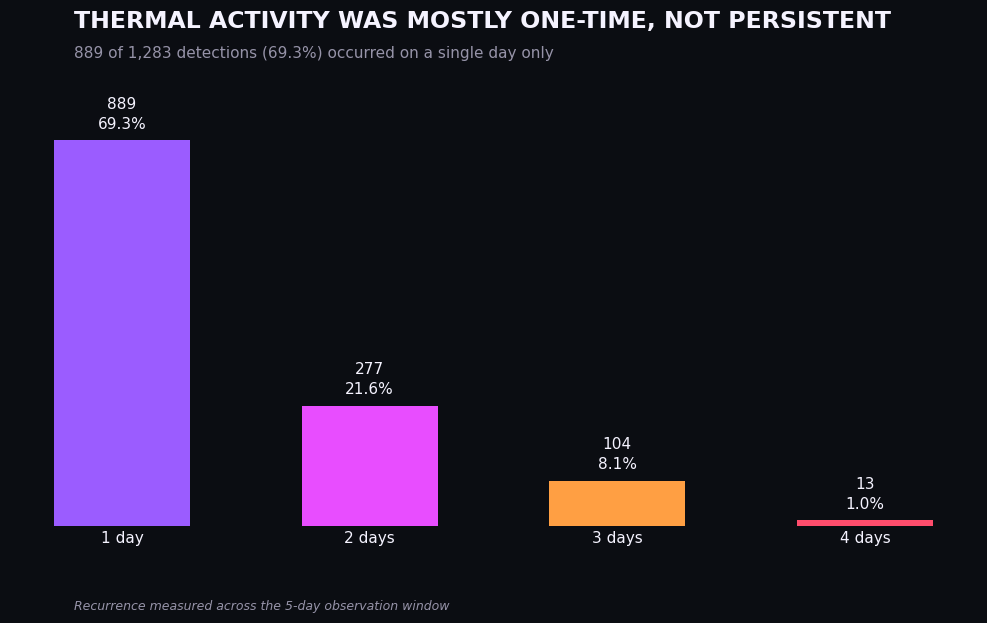

In [46]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\Hp\AntriX"
labeled = pd.read_csv(os.path.join(DATA_DIR, "firms_labeled.csv"))

rec_counts = labeled["recurrence_days"].value_counts().sort_index()
total = rec_counts.sum()

BG, TEXT, MUTED, BORDER = "#0B0D12", "#F5F3FF", "#9693A8", "#242633"
# gradient from cool (one-time) to hot (persistent) — meaningful, not decorative
bar_colors = ["#9B5CFF", "#E84DFF", "#FF9F43", "#FF4D6D"]

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)

x = rec_counts.index.values
y = rec_counts.values
pct = y / total * 100

bars = ax.bar(x, y, color=bar_colors[:len(x)], width=0.55, zorder=3)

for xi, yi, p in zip(x, y, pct):
    ax.text(xi, yi + total * 0.015, f"{yi:,}\n{p:.1f}%",
            ha="center", va="bottom", color=TEXT, fontsize=11, linespacing=1.4)

ax.set_xticks(x)
ax.set_xticklabels([f"{d} day{'s' if d > 1 else ''}" for d in x], color=TEXT, fontsize=11)
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

fig.text(0.08, 0.95, "THERMAL ACTIVITY WAS MOSTLY ONE-TIME, NOT PERSISTENT",
          fontsize=17, fontweight="bold", color=TEXT, ha="left")
fig.text(0.08, 0.90, f"{rec_counts[1]:,} of {total:,} detections ({pct[0]:.1f}%) occurred on a single day only",
          fontsize=11, color=MUTED, ha="left")
fig.text(0.08, -0.02, "Recurrence measured across the 5-day observation window",
          fontsize=9, color=MUTED, ha="left", style="italic")

plt.tight_layout(rect=[0, 0.06, 1, 0.86])

os.makedirs("antrix_visualizations", exist_ok=True)
plt.savefig("antrix_visualizations/04_persistence_recurrence.png", dpi=300, facecolor=BG, bbox_inches="tight")
plt.savefig("antrix_visualizations/04_persistence_recurrence.svg", facecolor=BG, bbox_inches="tight")
plt.show()

In [47]:
import os
import pandas as pd

DATA_DIR = r"C:\Users\Hp\AntriX"
labeled = pd.read_csv(os.path.join(DATA_DIR, "firms_labeled.csv"))

print(labeled["dist_to_industrial_km"].describe())
print("Missing:", labeled["dist_to_industrial_km"].isna().sum())
print("\nWithin 5km:", (labeled["dist_to_industrial_km"] <= 5).sum(),
      f"({(labeled['dist_to_industrial_km'] <= 5).mean()*100:.1f}%)")
print("\nBy label, % within 5km:")
print(labeled.groupby("label")["dist_to_industrial_km"].apply(lambda s: (s <= 5).mean()*100).round(1))
print("\nDistance stats by label:")
print(labeled.groupby("label")["dist_to_industrial_km"].describe())

count    1283.000000
mean      231.054211
std       192.125447
min         0.111551
25%         5.172106
50%       253.738738
75%       399.835172
max       729.325316
Name: dist_to_industrial_km, dtype: float64
Missing: 0

Within 5km: 314 (24.5%)

By label, % within 5km:
label
industrial             100.0
possible_industrial    100.0
unknown_other            9.8
Name: dist_to_industrial_km, dtype: float64

Distance stats by label:
                      count        mean         std       min        25%  \
label                                                                      
industrial            128.0    0.966960    0.498135  0.112192   0.546750   
possible_industrial    81.0    0.883717    0.516333  0.111551   0.474621   
unknown_other        1074.0  275.835382  178.269691  2.073894  83.548973   

                            50%         75%         max  
label                                                    
industrial             0.944780    1.275654    1.924771  
possible_

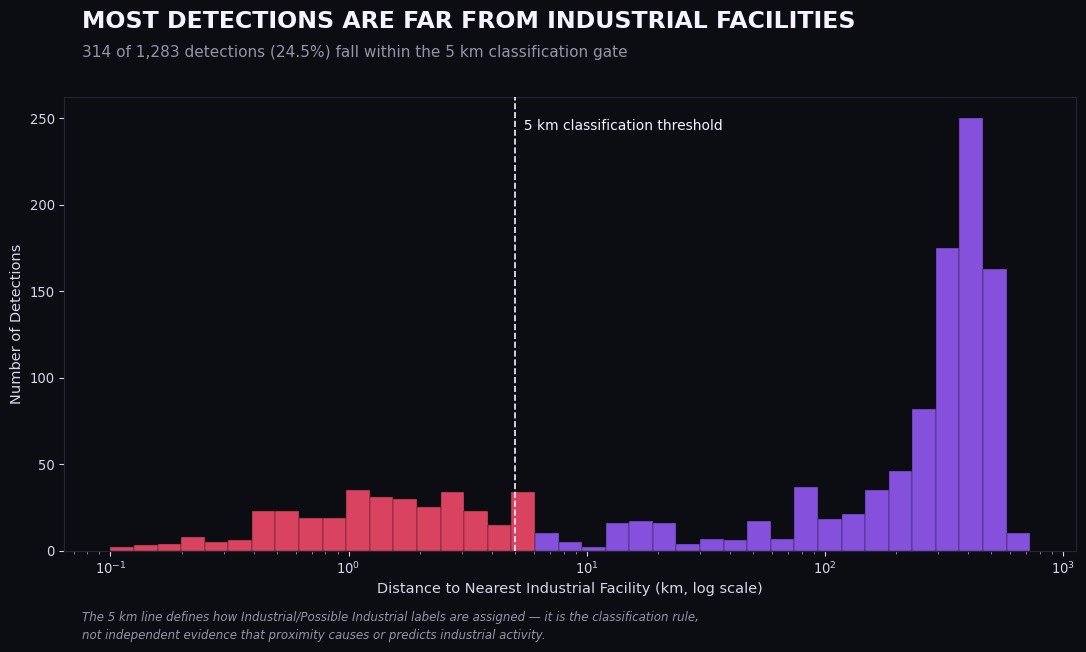

In [48]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\Hp\AntriX"
labeled = pd.read_csv(os.path.join(DATA_DIR, "firms_labeled.csv"))

BG, TEXT, MUTED, BORDER = "#0B0D12", "#F5F3FF", "#9693A8", "#242633"
LABEL = "#D8D6E8"

dist = labeled["dist_to_industrial_km"].values
dist_pos = dist[dist > 0]  # log scale needs >0; only affects bin edges, not real values

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor=BG)
ax.set_facecolor(BG)

bins = np.logspace(np.log10(0.1), np.log10(dist.max()), 40)
counts, edges, patches = ax.hist(dist, bins=bins, color="#9B5CFF", alpha=0.85,
                                  edgecolor=BG, linewidth=0.3, zorder=3)

# highlight bins under the 5km threshold in the "hot" color
for patch, left_edge in zip(patches, edges[:-1]):
    if left_edge < 5:
        patch.set_facecolor("#FF4D6D")

ax.set_xscale("log")
ax.axvline(5, color=TEXT, linestyle="--", linewidth=1.2, zorder=4)
ax.text(5, ax.get_ylim()[1]*0.95, "  5 km classification threshold",
        color=TEXT, fontsize=10, va="top", ha="left")

ax.set_xlabel("Distance to Nearest Industrial Facility (km, log scale)", color=LABEL, fontsize=10.5)
ax.set_ylabel("Number of Detections", color=LABEL, fontsize=10.5)
ax.tick_params(colors=LABEL, labelsize=9.5)
for spine in ax.spines.values():
    spine.set_color(BORDER)

within5 = (labeled["dist_to_industrial_km"] <= 5).sum()
pct5 = within5 / len(labeled) * 100

fig.text(0.08, 0.96, "MOST DETECTIONS ARE FAR FROM INDUSTRIAL FACILITIES",
          fontsize=17, fontweight="bold", color=TEXT, ha="left")
fig.text(0.08, 0.915, f"{within5:,} of {len(labeled):,} detections ({pct5:.1f}%) fall within the 5 km classification gate",
          fontsize=11, color=MUTED, ha="left")
fig.text(0.08, 0.020,
         "The 5 km line defines how Industrial/Possible Industrial labels are assigned — it is the classification rule,\n"
         "not independent evidence that proximity causes or predicts industrial activity.",
         fontsize=8.5, color=MUTED, ha="left", style="italic", linespacing=1.5)

plt.tight_layout(rect=[0, 0.06, 1, 0.88])

os.makedirs("antrix_visualizations", exist_ok=True)
plt.savefig("antrix_visualizations/05_facility_proximity.png", dpi=300, facecolor=BG, bbox_inches="tight")
plt.savefig("antrix_visualizations/05_facility_proximity.svg", facecolor=BG, bbox_inches="tight")
plt.show()

In [32]:
print(labeled["acq_date"].value_counts().sort_index())
print("\nacq_time sample:", labeled["acq_time"].head(10).tolist())
print("acq_time dtype:", labeled["acq_time"].dtype)

acq_date
2026-08-18    177
2026-08-19    373
2026-08-20    366
2026-08-21    366
2026-08-22      1
Name: count, dtype: int64

acq_time sample: [712, 712, 852, 852, 852, 852, 852, 852, 852, 852]
acq_time dtype: int64


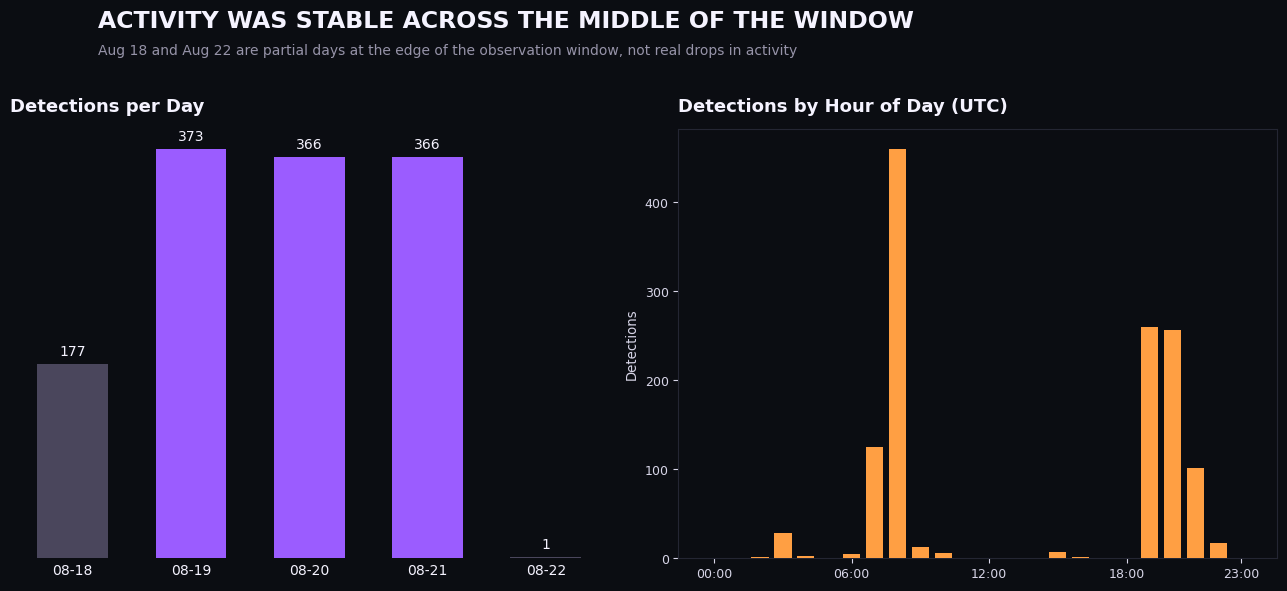

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\Hp\AntriX"
labeled = pd.read_csv(os.path.join(DATA_DIR, "firms_labeled.csv"))

BG, TEXT, MUTED, BORDER = "#0B0D12", "#F5F3FF", "#9693A8", "#242633"
LABEL = "#D8D6E8"

# derive hour of day from acq_time (HHMM int)
labeled["hour"] = (labeled["acq_time"] // 100).astype(int)

daily = labeled["acq_date"].value_counts().sort_index()
hourly = labeled["hour"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 6), facecolor=BG)

# ---- Panel A: detections per day ----
ax = axes[0]
ax.set_facecolor(BG)
day_colors = ["#9B5CFF" if i not in (0, len(daily)-1) else "#4A465C" for i in range(len(daily))]
bars = ax.bar(range(len(daily)), daily.values, color=day_colors, width=0.6, zorder=3)
for i, v in enumerate(daily.values):
    ax.text(i, v + 8, f"{v}", ha="center", color=TEXT, fontsize=10)

ax.set_xticks(range(len(daily)))
ax.set_xticklabels([d[-5:] for d in daily.index], color=TEXT, fontsize=10)  # MM-DD
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
ax.set_title("Detections per Day", color=TEXT, fontsize=13, fontweight="bold", loc="left", pad=12)

# ---- Panel B: detections by hour of day ----
ax2 = axes[1]
ax2.set_facecolor(BG)
all_hours = np.arange(24)
hourly_full = hourly.reindex(all_hours, fill_value=0)
ax2.bar(all_hours, hourly_full.values, color="#FF9F43", width=0.75, zorder=3)

ax2.set_xticks([0, 6, 12, 18, 23])
ax2.set_xticklabels(["00:00", "06:00", "12:00", "18:00", "23:00"], color=LABEL, fontsize=9.5)
ax2.set_ylabel("Detections", color=LABEL, fontsize=9.5)
ax2.tick_params(colors=LABEL, labelsize=9)
for spine in ax2.spines.values():
    spine.set_color(BORDER)
ax2.set_title("Detections by Hour of Day (UTC)", color=TEXT, fontsize=13, fontweight="bold", loc="left", pad=12)

fig.text(0.08, 0.97, "ACTIVITY WAS STABLE ACROSS THE MIDDLE OF THE WINDOW",
          fontsize=17, fontweight="bold", color=TEXT, ha="left")
fig.text(0.08, 0.925,
         "Aug 18 and Aug 22 are partial days at the edge of the observation window, not real drops in activity",
         fontsize=10, color=MUTED, ha="left")

plt.tight_layout(rect=[0, 0.02, 1, 0.88])

os.makedirs("antrix_visualizations", exist_ok=True)
plt.savefig("antrix_visualizations/06_temporal_activity.png", dpi=300, facecolor=BG, bbox_inches="tight")
plt.savefig("antrix_visualizations/06_temporal_activity.svg", facecolor=BG, bbox_inches="tight")
plt.show()

In [70]:
print(labeled["daynight"].value_counts())

daynight
N    643
D    640
Name: count, dtype: int64


In [72]:
print("satellite:")
print(labeled["satellite"].value_counts())
print("\ninstrument:")
print(labeled["instrument"].value_counts())
print("\nsource_sensor:")
print(labeled["source_sensor"].value_counts())
print("\nconfidence:")
print(labeled["confidence"].value_counts())

satellite:
satellite
N20      633
N        581
Terra     39
Aqua      30
Name: count, dtype: int64

instrument:
instrument
VIIRS    1214
MODIS      69
Name: count, dtype: int64

source_sensor:
source_sensor
VIIRS_NOAA20_NRT    633
VIIRS_SNPP_NRT      581
MODIS_NRT            69
Name: count, dtype: int64

confidence:
confidence
n      1168
l        38
h         8
59        5
100       5
63        3
61        3
68        3
71        3
65        3
74        2
37        2
43        2
0         2
75        2
23        2
49        2
60        2
69        2
32        2
53        2
51        2
52        1
42        1
58        1
46        1
28        1
25        1
30        1
90        1
18        1
83        1
76        1
80        1
48        1
85        1
55        1
62        1
33        1
50        1
70        1
40        1
Name: count, dtype: int64


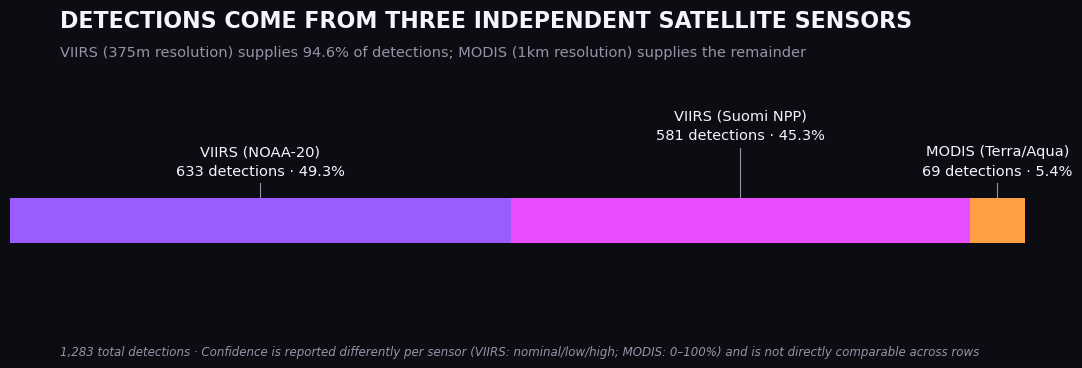

In [74]:
import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\Hp\AntriX"
labeled = pd.read_csv(os.path.join(DATA_DIR, "firms_labeled.csv"))

BG, TEXT, MUTED, BORDER = "#0B0D12", "#F5F3FF", "#9693A8", "#242633"

sensor_counts = labeled["source_sensor"].value_counts()
total = sensor_counts.sum()

order = ["VIIRS_NOAA20_NRT", "VIIRS_SNPP_NRT", "MODIS_NRT"]
sensor_counts = sensor_counts.reindex(order)

labels_display = {
    "VIIRS_NOAA20_NRT": "VIIRS (NOAA-20)",
    "VIIRS_SNPP_NRT": "VIIRS (Suomi NPP)",
    "MODIS_NRT": "MODIS (Terra/Aqua)",
}
colors = {
    "VIIRS_NOAA20_NRT": "#9B5CFF",
    "VIIRS_SNPP_NRT": "#E84DFF",
    "MODIS_NRT": "#FF9F43",
}

fig, ax = plt.subplots(figsize=(11, 3.6), facecolor=BG)
ax.set_facecolor(BG)

bar_y, bar_h = 0.35, 0.18
x = 0.0
label_offsets = [0.06, 0.20, 0.06]

for i, cat in enumerate(order):
    w = sensor_counts[cat] / total
    ax.add_patch(plt.Rectangle((x, bar_y), w, bar_h,
                                facecolor=colors[cat], edgecolor="none", zorder=2))
    mid_x = x + w / 2
    label_y = bar_y + bar_h + label_offsets[i]
    ax.plot([mid_x, mid_x], [bar_y + bar_h, label_y], color=MUTED, lw=0.8, zorder=1)
    pct = sensor_counts[cat] / total * 100
    ax.text(mid_x, label_y + 0.02,
            f"{labels_display[cat]}\n{sensor_counts[cat]:,} detections · {pct:.1f}%",
            ha="center", va="bottom", color=TEXT, fontsize=10.5, linespacing=1.5)
    x += w

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

fig.text(0.06, 0.95, "DETECTIONS COME FROM THREE INDEPENDENT SATELLITE SENSORS",
          fontsize=16, fontweight="bold", color=TEXT, ha="left")
fig.text(0.06, 0.87, "VIIRS (375m resolution) supplies 94.6% of detections; MODIS (1km resolution) supplies the remainder",
          fontsize=10.5, color=MUTED, ha="left")
fig.text(0.06, 0.04,
         f"{total:,} total detections · Confidence is reported differently per sensor "
         "(VIIRS: nominal/low/high; MODIS: 0–100%) and is not directly comparable across rows",
         fontsize=8.5, color=MUTED, ha="left", style="italic")

plt.tight_layout(rect=[0, 0.06, 1, 0.85])

os.makedirs("antrix_visualizations", exist_ok=True)
plt.savefig("antrix_visualizations/07_sensor_breakdown.png", dpi=300, facecolor=BG, bbox_inches="tight")
plt.savefig("antrix_visualizations/07_sensor_breakdown.svg", facecolor=BG, bbox_inches="tight")
plt.show()

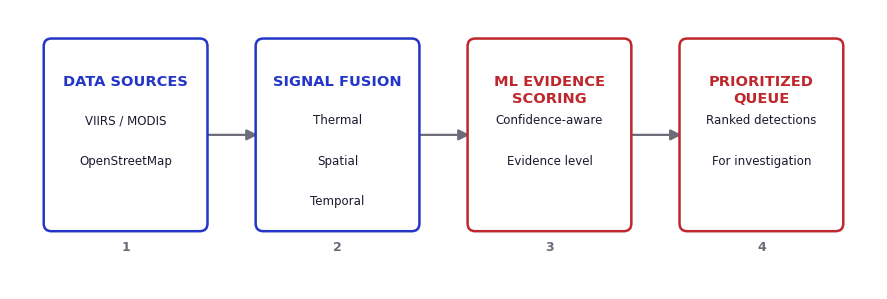

In [76]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ---- light theme to match this specific slide ----
BG = "#FFFFFF"
INK = "#1A1A2E"
BLUE = "#2436C7"       # matches the bold blue text in your bullets
RED = "#C0272D"        # matches your section header red
GRAY = "#6B6B7A"
BOX_BORDER = "#1A1A2E"

stages = [
    {"title": "DATA SOURCES", "items": ["VIIRS / MODIS", "OpenStreetMap"], "color": BLUE},
    {"title": "SIGNAL FUSION", "items": ["Thermal", "Spatial", "Temporal"], "color": BLUE},
    {"title": "ML EVIDENCE\nSCORING", "items": ["Confidence-aware", "Evidence level"], "color": RED},
    {"title": "PRIORITIZED\nQUEUE", "items": ["Ranked detections", "For investigation"], "color": RED},
]

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)

n = len(stages)
box_w, box_h = 1.6, 1.9
gap = 0.6
total_w = n * box_w + (n - 1) * gap
start_x = -total_w / 2

for i, stage in enumerate(stages):
    x = start_x + i * (box_w + gap)
    box = FancyBboxPatch((x, -box_h/2), box_w, box_h,
                          boxstyle="round,pad=0.05,rounding_size=0.08",
                          linewidth=1.8, edgecolor=stage["color"],
                          facecolor="white", zorder=3)
    ax.add_patch(box)

    ax.text(x + box_w/2, box_h/2 - 0.32, stage["title"],
            ha="center", va="top", fontsize=10.5, fontweight="bold",
            color=stage["color"], linespacing=1.3, zorder=4)

    item_y = 0.15
    for item in stage["items"]:
        ax.text(x + box_w/2, item_y, item, ha="center", va="center",
                fontsize=8.5, color=INK, zorder=4)
        item_y -= 0.42

    # step number badge
    ax.text(x + box_w/2, -box_h/2 - 0.22, f"{i+1}",
            ha="center", va="center", fontsize=9, fontweight="bold",
            color=GRAY, zorder=4)

    # arrow to next box
    if i < n - 1:
        arrow = FancyArrowPatch((x + box_w, 0), (x + box_w + gap, 0),
                                 arrowstyle="-|>", mutation_scale=16,
                                 linewidth=1.6, color=GRAY, zorder=2)
        ax.add_patch(arrow)

ax.set_xlim(start_x - 0.4, -start_x + 0.4)
ax.set_ylim(-1.6, 1.3)
ax.axis("off")
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("antrix_visualizations/00_pipeline_diagram.png", dpi=300,
            facecolor=BG, bbox_inches="tight")
plt.savefig("antrix_visualizations/00_pipeline_diagram.svg",
            facecolor=BG, bbox_inches="tight")
plt.show()

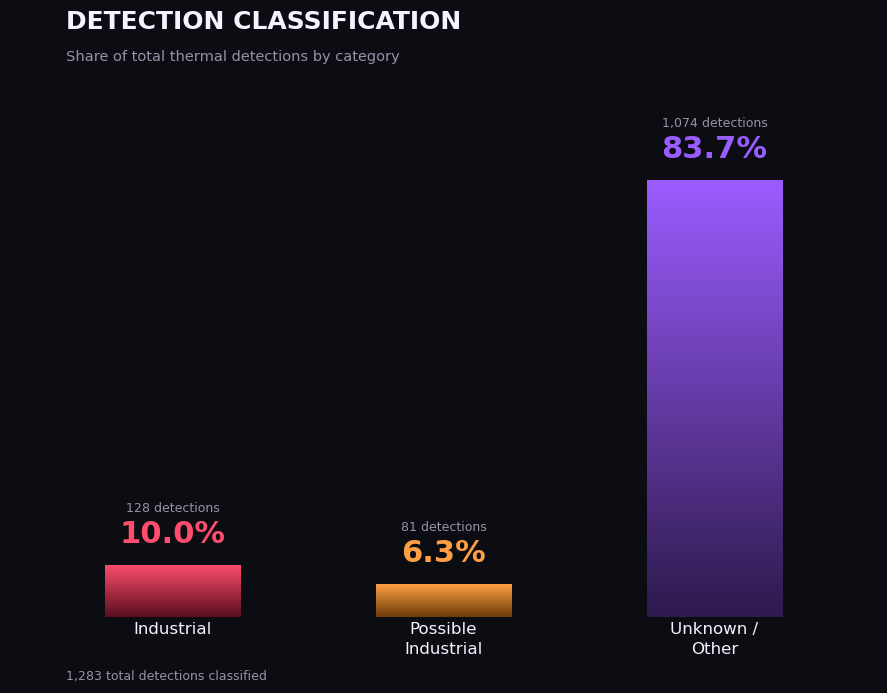

In [78]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

DATA_DIR = r"C:\Users\Hp\AntriX"
labeled = pd.read_csv(os.path.join(DATA_DIR, "firms_labeled.csv"))

counts = labeled["label"].value_counts()
total = counts.sum()

order = ["industrial", "possible_industrial", "unknown_other"]
counts = counts.reindex(order)

labels_display = {
    "industrial": "Industrial",
    "possible_industrial": "Possible\nIndustrial",
    "unknown_other": "Unknown /\nOther",
}

# each bar gets its own vertical gradient (dark base -> bright top), matching the thermal palette
gradients = {
    "industrial": ["#5A0E1E", "#FF4D6D"],
    "possible_industrial": ["#6B3B0A", "#FF9F43"],
    "unknown_other": ["#2E1A4D", "#9B5CFF"],
}

BG, TEXT, MUTED, BORDER = "#0B0D12", "#F5F3FF", "#9693A8", "#242633"

fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
ax.set_facecolor(BG)

bar_w = 0.5
x_positions = np.arange(len(order))

for i, cat in enumerate(order):
    pct = counts[cat] / total * 100
    x0 = x_positions[i] - bar_w / 2

    # build vertical gradient fill using imshow clipped to bar shape
    grad_cmap = LinearSegmentedColormap.from_list("bar_grad", gradients[cat])
    gradient_img = np.linspace(0, 1, 256).reshape(-1, 1)
    im = ax.imshow(gradient_img, extent=[x0, x0 + bar_w, 0, pct],
                   cmap=grad_cmap, aspect="auto", origin="lower", zorder=2)
    # clip to a rectangle so the gradient doesn't spill outside bar bounds
    clip_rect = Rectangle((x0, 0), bar_w, pct, transform=ax.transData)
    im.set_clip_path(clip_rect)

    # bold percentage label above the bar
    ax.text(x_positions[i], pct + total_max_offset if False else pct + 3,
            f"{pct:.1f}%", ha="center", va="bottom",
            fontsize=22, fontweight="bold", color=gradients[cat][1], zorder=3)
    # count as secondary line
    ax.text(x_positions[i], pct + 3 + 6.5, f"{counts[cat]:,} detections",
            ha="center", va="bottom", fontsize=9, color=MUTED, zorder=3)

ax.set_xticks(x_positions)
ax.set_xticklabels([labels_display[c] for c in order], color=TEXT, fontsize=12, linespacing=1.4)
ax.set_xlim(-0.6, len(order) - 0.4)
ax.set_ylim(0, 100)
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

fig.text(0.08, 0.95, "DETECTION CLASSIFICATION", fontsize=18, fontweight="bold", color=TEXT, ha="left")
fig.text(0.08, 0.905, "Share of total thermal detections by category", fontsize=10.5, color=MUTED, ha="left")
fig.text(0.08, 0.02, f"{total:,} total detections classified", fontsize=9, color=MUTED, ha="left")

plt.tight_layout(rect=[0, 0.03, 1, 0.88])

os.makedirs("antrix_visualizations", exist_ok=True)
plt.savefig("antrix_visualizations/02b_classification_gradient.png", dpi=300, facecolor=BG, bbox_inches="tight")
plt.savefig("antrix_visualizations/02b_classification_gradient.svg", facecolor=BG, bbox_inches="tight")
plt.show()

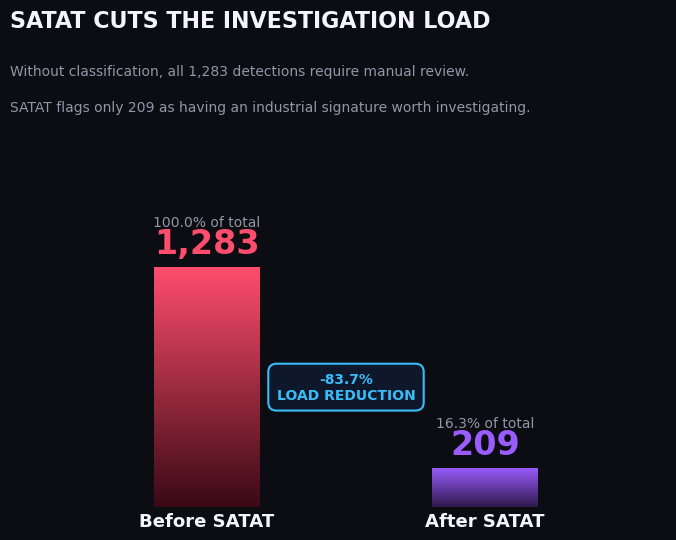

In [106]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd

DATA_DIR = r"C:\Users\Hp\AntriX"
labeled = pd.read_csv(os.path.join(DATA_DIR, "firms_labeled.csv"))

total = len(labeled)
actionable = (labeled["label"] != "unknown_other").sum()
reduction_pct = (1 - actionable / total) * 100

labels_x = ["Before SATAT", "After SATAT"]
raw_values = [total, actionable]
pct_values = [100.0, actionable / total * 100]

BG, TEXT, MUTED = "#0B0D12", "#F5F3FF", "#9693A8"
grad_colors = [["#3A0A14", "#FF4D6D"], ["#2E1A4D", "#9B5CFF"]]

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
fig.subplots_adjust(top=0.68, bottom=0.12, left=0.10, right=0.90)
ax.set_facecolor(BG)

bar_w = 0.38
x_positions = np.arange(len(labels_x))

for i, (raw, pct) in enumerate(zip(raw_values, pct_values)):
    x0 = x_positions[i] - bar_w / 2

    # Draw gradient bar
    grad_cmap = LinearSegmentedColormap.from_list("g", grad_colors[i])
    gradient_img = np.linspace(0, 1, 256).reshape(-1, 1)
    im = ax.imshow(
        gradient_img,
        extent=[x0, x0 + bar_w, 0, pct],
        cmap=grad_cmap,
        aspect="auto",
        origin="lower",
        zorder=2,
    )
    im.set_clip_path(Rectangle((x0, 0), bar_w, pct, transform=ax.transData))

    # --- PERFECT SEPARATED LABELS ---
    # Big Number (Bottom of label stack)
    ax.text(
        x_positions[i],
        pct + 3.0,
        f"{raw:,}",
        ha="center",
        va="bottom",
        fontsize=24,
        fontweight="bold",
        color=grad_colors[i][1],
        zorder=3,
    )

    # Subtext Percentage (Top of label stack - offset by +16 units so no overlap)
    ax.text(
        x_positions[i],
        pct + 16.0,
        f"{pct:.1f}% of total",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="medium",
        color=MUTED,
        zorder=3,
    )

# --- CLEAN MID-SECTION BADGE (No arrows to collide into text) ---
mid_x = (x_positions[0] + x_positions[1]) / 2

# Badge Box
ax.text(
    mid_x,
    50,
    f"-{reduction_pct:.1f}%\nLOAD REDUCTION",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color="#38BDF8",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#0F172A",
        edgecolor="#38BDF8",
        lw=1.5,
    ),
    zorder=5,
)

# Axis formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(labels_x, color=TEXT, fontsize=13, fontweight="bold")
ax.set_xlim(-0.65, len(labels_x) - 0.35)
ax.set_ylim(0, 140)  # Room for labels above 100% bar
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

# Title Block
fig.text(
    0.08,
    0.92,
    "SATAT CUTS THE INVESTIGATION LOAD",
    fontsize=16,
    fontweight="bold",
    color=TEXT,
    ha="left",
)
fig.text(
    0.08,
    0.84,
    f"Without classification, all {total:,} detections require manual review.",
    fontsize=10,
    color=MUTED,
    ha="left",
)
fig.text(
    0.08,
    0.78,
    f"SATAT flags only {actionable:,} as having an industrial signature worth investigating.",
    fontsize=10,
    color=MUTED,
    ha="left",
)

os.makedirs("antrix_visualizations", exist_ok=True)
plt.savefig(
    "antrix_visualizations/08_before_after_antrix.png",
    dpi=300,
    facecolor=BG,
    bbox_inches="tight",
)
plt.savefig(
    "antrix_visualizations/08_before_after_antrix.svg",
    facecolor=BG,
    bbox_inches="tight",
)
plt.show()